In [3]:
import json, os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

json_files = [
    'CellPhoneDB_ANN_ResNet_results.json',
    'CellPhoneDB_ANN_LeNet_results.json',
    'CellPhoneDB_ANN_AlexNet_results.json',
    'CellPhoneDB_ANN_VGGNet_results.json',
    'CellPhoneDB_ANN_GoogLeNet_results.json',
    'CellPhoneDB_ANN_ZFNet_results.json',
]

all_data = []
for f in json_files:
    if os.path.exists(f):
        with open(f) as fp:
            all_data.append(json.load(fp))
        print(f'✓ Loaded {f}')
    else:
        print(f'✗ NOT FOUND: {f} — run that notebook first!')

member_names = [d['notebook'] for d in all_data]
ann_results  = {d['notebook']: d['ann'] for d in all_data}
cnn_results  = {d['notebook']: d['cnn'] for d in all_data}
metric_names = ['Accuracy', 'Precision', 'Recall', 'F1']

print(f'\nLoaded {len(all_data)} notebooks ✓')

✓ Loaded CellPhoneDB_ANN_ResNet_results.json
✓ Loaded CellPhoneDB_ANN_LeNet_results.json
✓ Loaded CellPhoneDB_ANN_AlexNet_results.json
✓ Loaded CellPhoneDB_ANN_VGGNet_results.json
✓ Loaded CellPhoneDB_ANN_GoogLeNet_results.json
✓ Loaded CellPhoneDB_ANN_ZFNet_results.json

Loaded 6 notebooks ✓


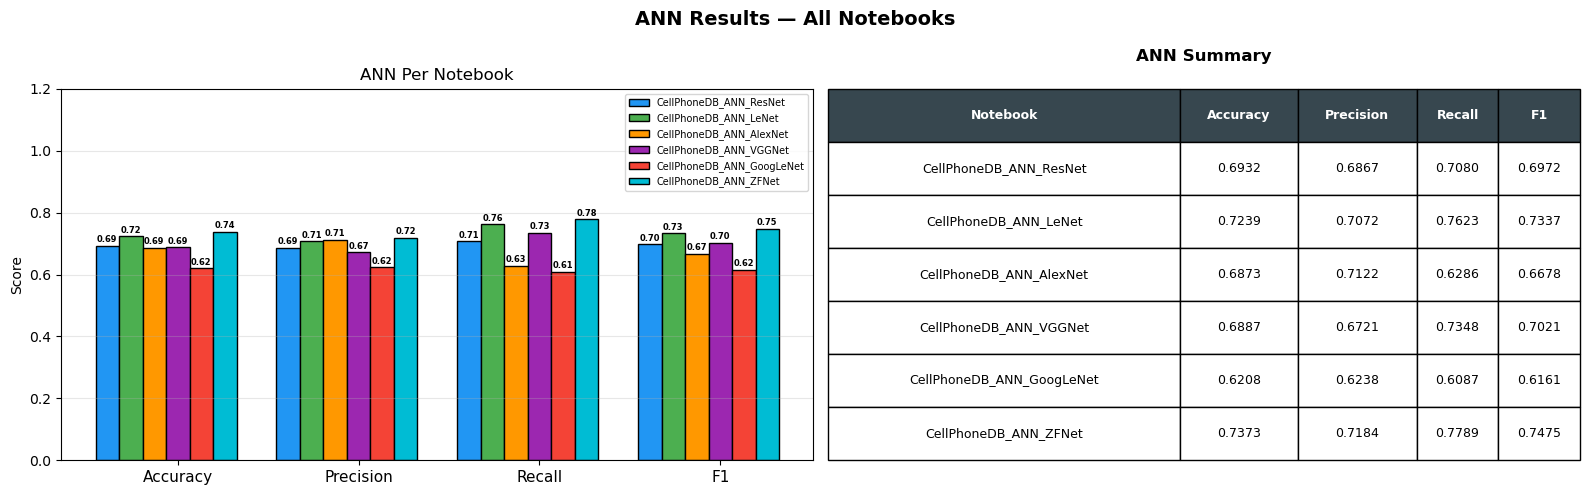

In [4]:
colors = ['#2196F3','#4CAF50','#FF9800','#9C27B0','#F44336','#00BCD4']
x      = np.arange(len(metric_names))
width  = 0.13

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('ANN Results — All Notebooks', fontsize=14, fontweight='bold')

ax = axes[0]
for i, (name, col) in enumerate(zip(member_names, colors)):
    vals = [ann_results[name][m] for m in metric_names]
    bars = ax.bar(x + i*width - 3*width, vals, width,
                  label=name, color=col, edgecolor='black')
    for bar in bars:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                f'{bar.get_height():.2f}', ha='center', va='bottom',
                fontsize=6, fontweight='bold')

ax.set_xticks(x); ax.set_xticklabels(metric_names, fontsize=11)
ax.set_ylim(0, 1.2); ax.set_ylabel('Score')
ax.set_title('ANN Per Notebook'); ax.legend(fontsize=7); ax.grid(axis='y', alpha=0.3)

ax = axes[1]
ax.axis('off')
table_data = [['Notebook', 'Accuracy', 'Precision', 'Recall', 'F1']]
for name in member_names:
    vals = [ann_results[name][m] for m in metric_names]
    table_data.append([name] + [f'{v:.4f}' for v in vals])
tbl = ax.table(cellText=table_data[1:], colLabels=table_data[0],
               cellLoc='center', loc='center', bbox=[0,0,1,1])
tbl.auto_set_font_size(False); tbl.set_fontsize(9)
tbl.auto_set_column_width([0,1,2,3,4])
for j in range(5):
    tbl[0,j].set_facecolor('#37474F')
    tbl[0,j].set_text_props(color='white', fontweight='bold')
ax.set_title('ANN Summary', fontsize=12, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('ann_all_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

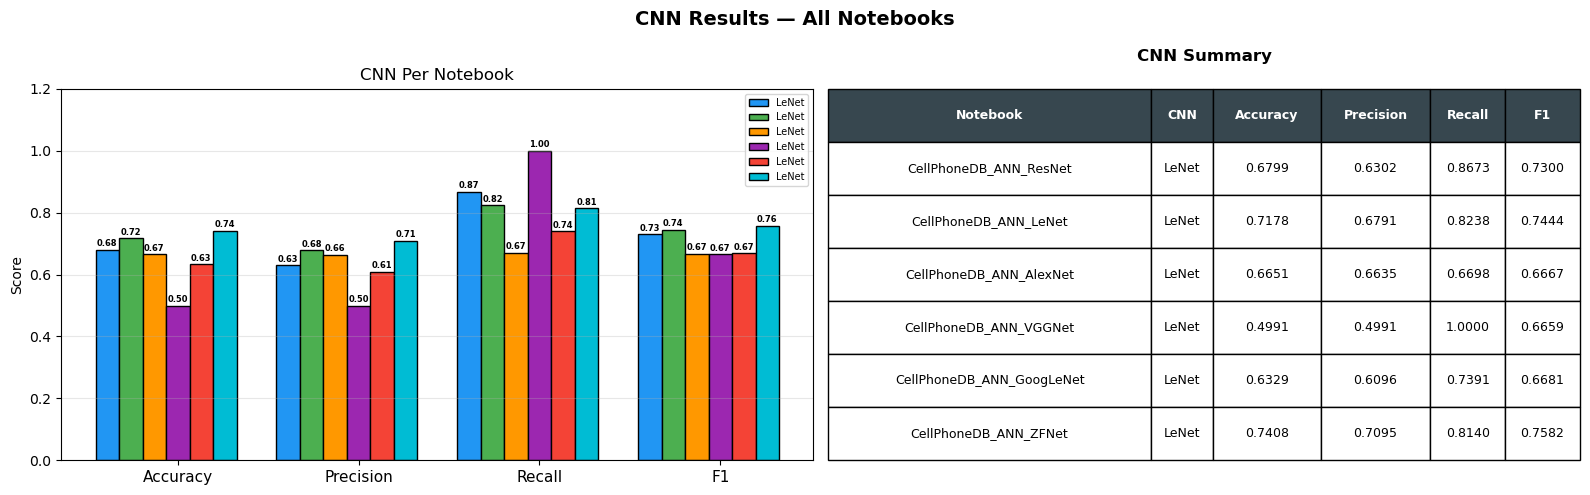

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('CNN Results — All Notebooks', fontsize=14, fontweight='bold')

ax = axes[0]
for i, (name, col) in enumerate(zip(member_names, colors)):
    vals  = [cnn_results[name][m] for m in metric_names]
    model = cnn_results[name]['model']
    bars  = ax.bar(x + i*width - 3*width, vals, width,
                   label=f'{model}', color=col, edgecolor='black')
    for bar in bars:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                f'{bar.get_height():.2f}', ha='center', va='bottom',
                fontsize=6, fontweight='bold')

ax.set_xticks(x); ax.set_xticklabels(metric_names, fontsize=11)
ax.set_ylim(0, 1.2); ax.set_ylabel('Score')
ax.set_title('CNN Per Notebook'); ax.legend(fontsize=7); ax.grid(axis='y', alpha=0.3)

ax = axes[1]
ax.axis('off')
table_data = [['Notebook', 'CNN', 'Accuracy', 'Precision', 'Recall', 'F1']]
for name in member_names:
    vals  = [cnn_results[name][m] for m in metric_names]
    model = cnn_results[name]['model']
    table_data.append([name, model] + [f'{v:.4f}' for v in vals])
tbl = ax.table(cellText=table_data[1:], colLabels=table_data[0],
               cellLoc='center', loc='center', bbox=[0,0,1,1])
tbl.auto_set_font_size(False); tbl.set_fontsize(9)
tbl.auto_set_column_width([0,1,2,3,4,5])
for j in range(6):
    tbl[0,j].set_facecolor('#37474F')
    tbl[0,j].set_text_props(color='white', fontweight='bold')
ax.set_title('CNN Summary', fontsize=12, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('cnn_all_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

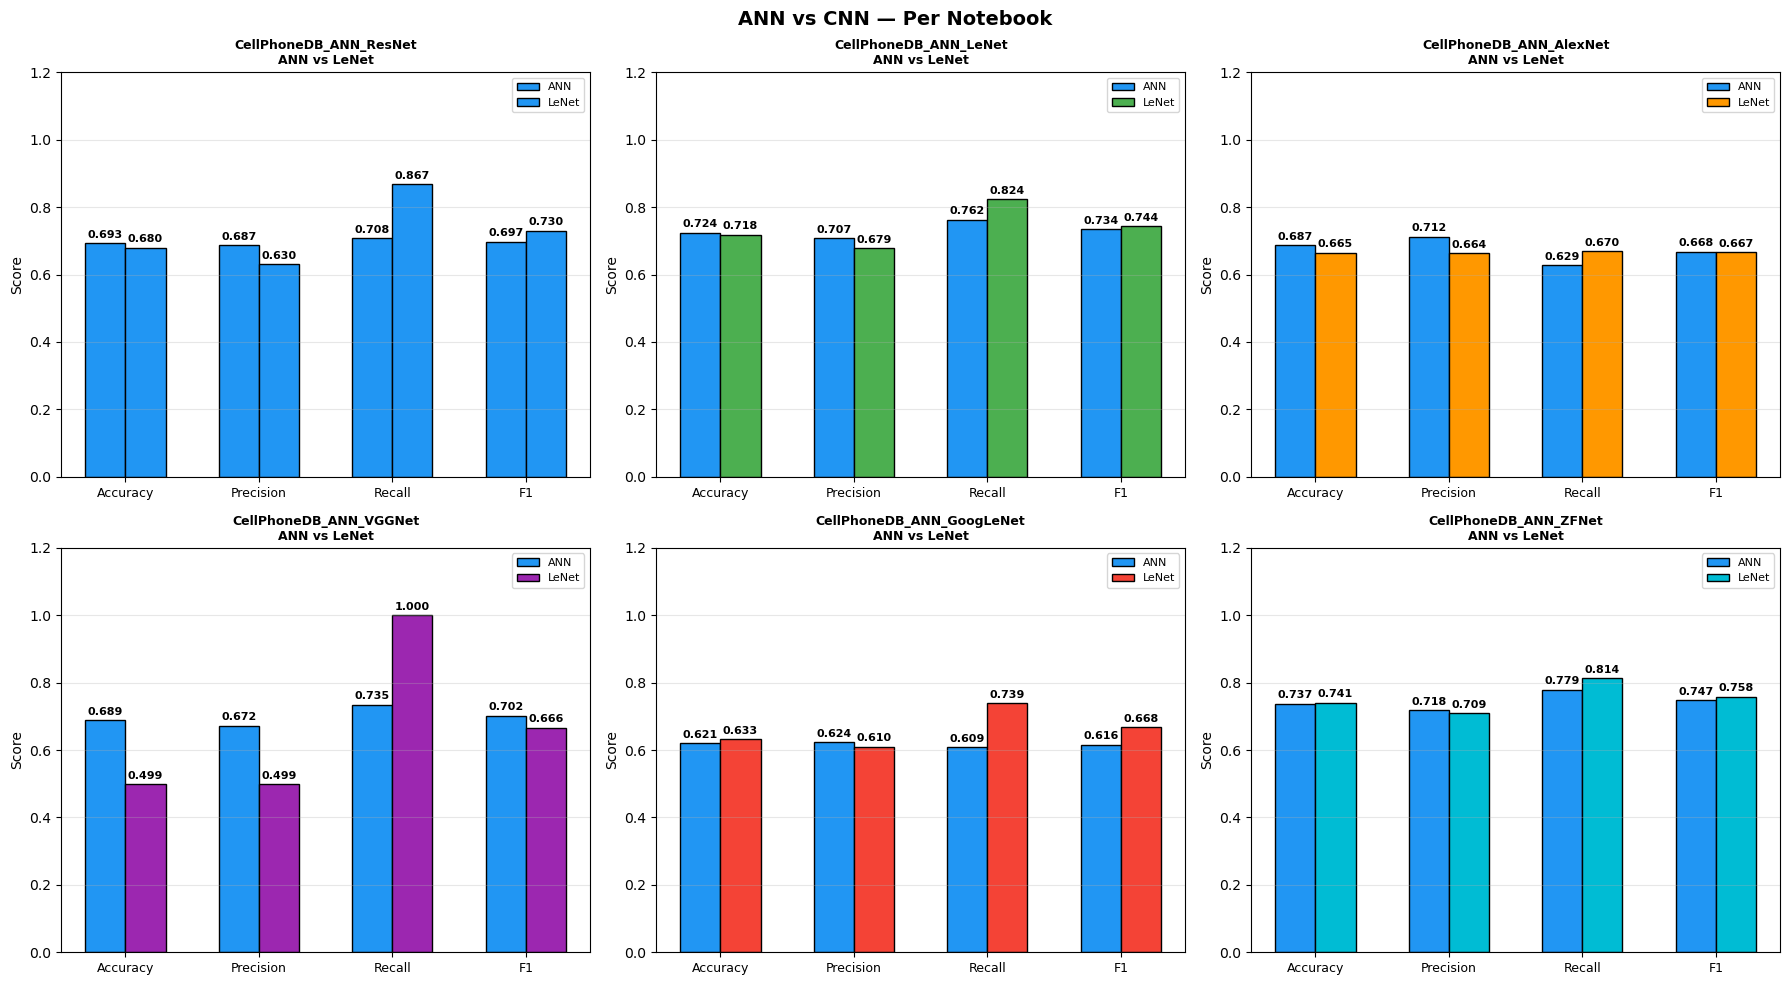

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('ANN vs CNN — Per Notebook', fontsize=14, fontweight='bold')
axes = axes.flatten()

for i, (name, col) in enumerate(zip(member_names, colors)):
    ax       = axes[i]
    ann_vals = [ann_results[name][m] for m in metric_names]
    cnn_vals = [cnn_results[name][m] for m in metric_names]
    model    = cnn_results[name]['model']

    xp    = np.arange(len(metric_names))
    w     = 0.3
    b1    = ax.bar(xp - w/2, ann_vals, w, label='ANN',  color='#2196F3', edgecolor='black')
    b2    = ax.bar(xp + w/2, cnn_vals, w, label=model,  color=col,       edgecolor='black')

    for bar in list(b1)+list(b2):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                f'{bar.get_height():.3f}', ha='center', va='bottom',
                fontsize=8, fontweight='bold')

    ax.set_xticks(xp); ax.set_xticklabels(metric_names, fontsize=9)
    ax.set_ylim(0, 1.2); ax.set_ylabel('Score')
    ax.set_title(f'{name}\nANN vs {model}', fontweight='bold', fontsize=9)
    ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('per_notebook_ann_vs_cnn.png', dpi=150, bbox_inches='tight')
plt.show()